# Notebook 02：标签构造与数据清洗

本 Notebook 首先冻结多因子研究的预测目标（label）口径，再据此清洗和对齐数据。工作流为先定义 label → 清洗原始数据 → 计算 label → 再清洗和验证 label。主标签记为 `future_return_1m`，表示股票在相邻两个正式月末调仓日之间的复权收盘价简单收益。

> 本节是后续因子检验、模型训练和样本外评估共同遵守的定义。若以后修改价格时点、持有期或异常状态处理规则，必须生成新字段名或新版本，不能静默覆盖已有标签。

## 1. 主标签定义

对于股票 $i$ 和月末调仓日 $t$，定义未来一个调仓周期收益：

$$
R_{i,t+1}=\frac{P^{adj}_{i,t+1}}{P^{adj}_{i,t}}-1
$$

并保存为：

```text
future_return_1m
```

这里作出以下确定选择：

- **收益类型**：简单收益率，不使用对数收益率。
- **收益对象**：个股原始总收益，不减市场收益或行业收益。超额收益可在评估阶段另行构造，但不替换主标签。
- **持有周期**：从正式调仓日 $t$ 到下一次正式调仓日 $t+1$，通常约为一个自然月，但天数不固定。
- **价格时点**：两个调仓日的收盘价，即 close-to-close。
- **价格口径**：使用复权收盘价，`adjusted_close = close * adj_factor`。复权价的绝对尺度无关紧要，只要同一股票跨期口径一致。
- **计价单位**：标签以小数保存，例如 `0.05` 表示 5%，不保存成 `5`。
- **交易成本**：主标签不扣佣金、印花税、滑点和冲击成本；这些属于组合回测层，而不是股票收益预测目标。

该定义严格采用 README 的基础公式。它适合做因子 IC、分组收益和横截面预测研究，但不等同于完全可成交的策略收益：如果因子也使用了调仓日收盘信息，就不能声称在同一收盘价完成交易。正式组合回测应另用下一交易日开盘成交规则。

## 2. 现有 processed 字段核对

主标签收益公式可以由 `data/processed/universe_monthly.parquet` 构造；为了准确解释终点记录缺失原因，还要连接 `data/raw/suspend_d/` 中各月末调仓日的停牌分区。收益公式直接使用以下原字段名：

| 原字段名 | 来源 | 用途 |
|---|---|---|
| `stock_code` | `universe_monthly.parquet` | 股票键，保证收益在同一股票内部对齐 |
| `date` | `universe_monthly.parquet` | 信号日及月末调仓日序列 |
| `close` | `universe_monthly.parquet` | 月末未复权收盘价 |
| `adj_factor` | `universe_monthly.parquet` | 与 `close` 相乘得到复权收盘价 |

以下现有字段不直接进入收益公式，但用于样本选择和状态审计：

| 原字段名 | 用途 |
|---|---|
| `is_eligible` | 判断股票在信号日 $t$ 是否属于主研究样本 |
| `is_suspended` | 判断起点或存在终点记录时的停牌状态 |
| `is_buyable` | 判断信号日是否具备基础可买性 |
| `is_one_price_limit_up` | 审计一字涨停导致的建仓限制 |
| `is_one_price_limit_down` | 审计终点一字跌停导致的退出限制 |
| `delist_date` | 在终点记录缺失时辅助识别持有期内退市 |
| `financial_available_date` | 验证信号日财务特征不存在未来信息 |

停牌分区中的 `ts_code` 和 `trade_date` 在清洗阶段统一改名为 `stock_code` 和 `date`，只用于识别终点是否停牌；停牌分区是否存在则记录为逐日覆盖字段 `suspension_data_available`。

`price_daily.parquet` 中也存在同名的 `stock_code`、`date`、`close`、`adj_factor`、`is_one_price_limit_up` 和 `is_one_price_limit_down`。它主要用于复核日频路径、复牌和极端收益，不是构造月末主标签的必需输入。

后文的 `adjusted_close_t`、`adjusted_close_t1`、`label_start_date`、`label_end_date`、`future_return_1m`、`label_available`、`label_status` 和 `exit_blocked` 都是由上述原字段计算得到的**新字段**，不是对源数据字段名的假设。

## 3. 日期和逐股对齐规则

1. 现有 `universe_monthly.parquet` 已按全市场交易日历保留每个自然月最后一个开市日；实际构造时使用其 `date` 字段的有序唯一值作为调仓日序列，不使用自然月最后一天。
2. $t+1$ 必须是上述 `date` 序列中紧接 $t$ 的下一项，而不是某只股票自己的“下一条可用记录”。
3. 标签必须在每只股票内部计算，并以 `(date, stock_code)` 为唯一主键；禁止对整张表直接 `shift(-1)`。
4. 起点和终点价格都必须恰好来自对应的正式调仓日。股票在月末无行情时，不得用更早的价格向前填充，也不得跳到下一个有行情的月份。
5. 标签记录仍归属于信号形成日 $t$。建议额外保存 `label_start_date=t` 和 `label_end_date=t+1`，便于审计。
6. 样本最后一个调仓日由于没有下一期终点，`future_return_1m` 必须为缺失，状态记为 `right_censored`，不得补零。

以上规则防止把停牌跨期累计变化误当成普通月收益，也防止股票之间或不相邻月份之间发生错位。

## 4. 股票池与样本选择

标签可以先为所有具备合法起止价格的月末记录计算，以便审计；进入因子检验或模型训练的主样本必须同时满足：

```text
is_eligible == True at t
label_available == True
```

只使用信号形成日 $t$ 的 `is_eligible`，**不得要求股票在 $t+1$ 仍然属于股票池**。用未来的 ST 状态、未来行业、未来市值完整性或未来 `is_eligible` 筛选当前样本，会造成前视偏差和幸存者偏差。

同理，构造 $t$ 时点特征时：

- 财务数据必须满足 `financial_available_date <= t`；
- 行业必须使用 $t$ 时点有效的历史行业；
- 不能使用 $t+1$ 的任何字段填补 $t$ 的特征；
- `future_return_1m` 只能作为预测目标，不能参与因子缺失填补、去极值阈值估计或股票池选择。

## 5. 价格清洗与特殊状态处理

### 5.1 公司行为和价格合法性

- 分红、送转、拆并股等公司行为通过 `adj_factor` 处理，禁止直接用未复权 `close` 计算跨月收益。
- `close` 或 `adj_factor` 缺失、非有限数或小于等于 0 时，标签无效。
- `(date, stock_code)` 重复记录必须在标签构造前报错，不能随意保留第一条或最后一条。
- 不对价格做横截面填充，不使用行业均值、中位数或前值替代真实交易价格。

### 5.2 停牌

- 若股票在起点 $t$ 停牌，它本就不应通过当期 `is_eligible`。
- 若终点记录存在且其 `is_suspended=True`，主标签记为缺失，`label_available=False`。
- 完整月度骨架会保留月末停牌股票，因此终点停牌直接使用下一月度记录的 `is_suspended` 判断；若下一月末仍不存在整行记录，则结合 `delist_date` 和停牌分区覆盖状态区分 `delisted_no_exit_price`、`market_data_missing` 与 `other_missing_exit_record`。禁止使用停牌前的陈旧收盘价。
- 复牌后的第一条收益可能包含整个停牌期的累计变化。只要起止点恰好是相邻调仓日且两端均有合法行情，可以保留；日频极值分析中则不能把它解释为普通单日收益。

### 5.3 涨跌停

- 涨跌停收盘价仍是真实市场价格，因此不因普通涨停或跌停而删除主标签。
- 起点一字涨停股票由当期 `is_buyable` 和最终的 `is_eligible` 排除，避免假设可以建仓。
- 终点一字跌停由 $t+1$ 行的 `is_one_price_limit_down` 识别。它可能无法卖出，但仍保留 close-to-close 主标签，同时令派生字段 `exit_blocked=True`。可实现收益应在组合回测中按延迟卖出规则另算。

### 5.4 退市和终点价格缺失

- 不使用 $t+1$ 的股票池成员资格筛除退市股票。
- 若股票在持有期内退市且没有可信的终点成交价或退市现金价值，`future_return_1m` 记为缺失，`label_status='delisted_no_exit_price'`；不得武断填成 0 或 -100%。
- 这类记录必须单独计数并披露。若数量不可忽略，正式研究应补充退市收益或现金清偿数据并做稳健性检验，避免幸存者偏差。

## 6. 极端收益和缺失值政策

主标签保存真实、未经截尾的复权简单收益：

- 不因为超过 10%、20% 或 100% 就自动删除；A 股涨跌幅制度、新股和长期停牌复牌都可能产生真实极端值。
- 先核查复权因子跳变、价格单位、重复记录、日期错位和停牌间隔，再判断是否为数据错误。
- 经核查确认是数据错误且无法修复时，将标签设为缺失并记录原因，不用人工指定一个替代收益。
- `NaN`、正负无穷值均视为不可用；有效简单收益的理论下界为 -100%，因此小于 -1 的结果必须报错检查。
- 主标签不做 winsorization。若线性回归对尾部过于敏感，可以额外生成按月横截面 1%/99% 缩尾的辅助标签，例如 `future_return_1m_winsor`；Rank IC、分组回测和最终收益报告仍优先使用原始标签。

标签缺失不能填 0，因为 0 表示已经观察到“收益恰好为零”，与无法观察未来收益完全不同。

## 7. 输出字段与状态码

本 Notebook 保存三份处理结果：

- `data/processed/price_daily_clean.parquet`：清洗后的日频行情，供日频因子直接使用；
- `data/processed/universe_monthly_clean.parquet`：清洗后的月度股票池；
- `data/processed/monthly_panel.parquet`：加入未来收益标签的月度研究面板。

其中 `monthly_panel.parquet` 至少保留以下标签审计字段：

| 字段 | 含义 |
|---|---|
| `date` | 信号形成日，即 $t$ |
| `stock_code` | 股票代码 |
| `label_start_date` | 标签起点，等于 $t$ |
| `label_end_date` | 调仓日历中紧接的下一调仓日 |
| `adjusted_close_t` | 起点复权收盘价 |
| `adjusted_close_t1` | 终点复权收盘价 |
| `future_return_1m` | 主标签 |
| `label_available` | 主标签是否可用于研究 |
| `label_status` | 标签有效或无效的原因 |
| `exit_blocked` | 终点是否存在一字跌停等退出受阻情形 |
| `suspension_data_available_t1` | 终点日期的停牌分区是否存在 |
| `is_suspended_t1` | 从清洗后月度股票池取得的终点停牌标记 |

`label_status` 使用固定枚举，建议包括：

```text
valid
right_censored
missing_start_price
market_data_missing
other_missing_exit_record
missing_exit_price
suspended_at_exit
delisted_no_exit_price
invalid_price
invalid_return
```

状态码应互斥；若一条记录同时命中多个问题，按“样本末端 → 退市 → 已知停牌 → 缺终点记录 → 缺价格 → 非法价格 → 非法收益”的优先级记录首要原因，并可另保留布尔诊断字段。

## 8. 实现约束

实现时应采用显式的下一调仓日映射和键连接，而不是依赖当前排序碰巧正确：

```python
# 伪代码：具体实现应放入 src/data/label.py
rebalance_dates = sorted(universe_monthly['date'].unique())
next_date = {d: rebalance_dates[j + 1] for j, d in enumerate(rebalance_dates[:-1])}

panel = universe_monthly.copy()
panel['label_start_date'] = panel['date']
panel['label_end_date'] = panel['date'].map(next_date)
panel['adjusted_close_t'] = panel['close'] * panel['adj_factor']

# 终点表只使用 universe_monthly 中真实存在的同名字段
endpoint_prices = universe_monthly[[
    'date', 'stock_code', 'close', 'adj_factor',
    'is_suspended', 'is_one_price_limit_down'
]].rename(columns={
    'date': 'label_end_date',
    'close': 'close_t1',
    'adj_factor': 'adj_factor_t1',
    'is_suspended': 'is_suspended_t1',
    'is_one_price_limit_down': 'is_one_price_limit_down_t1',
})
endpoint_prices['adjusted_close_t1'] = (
    endpoint_prices['close_t1'] * endpoint_prices['adj_factor_t1']
)

# 按 (label_end_date, stock_code) 精确连接，不允许按最近日期回填
panel = panel.merge(endpoint_prices, on=['label_end_date', 'stock_code'], how='left')
panel['future_return_1m'] = (
    panel['adjusted_close_t1'] / panel['adjusted_close_t'] - 1.0
)
panel['exit_blocked'] = panel['is_one_price_limit_down_t1'].fillna(False)
```

为了不把研究逻辑散落在 Notebook 中，正式计算函数应放在 `src/data/label.py`；本 Notebook 负责调用、诊断、画图和解释。

## 9. 构造完成后的强制检查

标签数据至少通过以下检查后才能进入因子研究：

1. `(date, stock_code)` 无重复。
2. 所有有效记录满足 `label_end_date > label_start_date`，且二者为相邻调仓日。
3. 随机抽样若干股票，手工复算 $P^{adj}_{t+1}/P^{adj}_t-1$。
4. 最后一个调仓日的标签全部为 `right_censored`。
5. 有效标签均为有限数且不小于 -1。
6. 按月报告标签覆盖率、缺失原因和极端收益数量。
7. 分别检查停牌、复牌、新股、涨跌停和退市样本。
8. 核对训练样本只使用 $t$ 时点 `is_eligible=True`，没有使用 $t+1$ 状态筛选。
9. 核对所有财务特征满足 `financial_available_date <= date`。
10. 保存标签定义版本、生成时间和源数据日期范围，保证结果可复现。

## 最终口径总结

> `future_return_1m` 是股票从本月正式调仓日到下一正式调仓日的复权收盘价简单收益。标签按股票和相邻调仓日精确对齐，不回填缺失价格，不扣交易成本，不做缩尾；研究样本仅按信号形成日的股票池资格筛选。不可观测、停牌终点和无可信退出价格的退市记录保留在面板中并以状态码标记，但不进入主样本。

## 10. 可执行工作流

下面的单元格按固定顺序完成：

```text
读取 processed 数据和月末停牌分区
→ 清洗 price_daily、universe_monthly 和停牌状态
→ 检查缺失率、特殊状态和月末日期
→ 构造 future_return_1m
→ 构造并验收 monthly_panel
→ 保存清洗后的日频面板、月度股票池和 monthly_panel
```

核心逻辑分别来自 `src/data/clean.py` 和 `src/data/label.py`。Notebook 只负责组织流程、展示诊断和执行验收，避免产生另一份不一致的计算实现。

In [1]:
from pathlib import Path
import gc
import sys

import numpy as np
import pandas as pd
from IPython.display import display

# 同时兼容从项目根目录和 notebooks/ 目录启动 Notebook。
WORKING_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = (
    WORKING_DIRECTORY
    if (WORKING_DIRECTORY / 'src').is_dir()
    else WORKING_DIRECTORY.parent
)
if not (PROJECT_ROOT / 'src').is_dir():
    raise FileNotFoundError('无法定位项目根目录，请从项目根目录或 notebooks/ 运行。')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.clean import run_cleaning_workflow, save_cleaned_panels
from src.data.label import (
    build_label_quality_report,
    build_monthly_panel,
    label_status_counts,
    save_monthly_panel,
)

RAW_DIRECTORY = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIRECTORY = PROJECT_ROOT / 'data' / 'processed'
SUSPENSION_DIRECTORY = RAW_DIRECTORY / 'suspend_d'
PRICE_DAILY_PATH = PROCESSED_DIRECTORY / 'price_daily.parquet'
UNIVERSE_MONTHLY_PATH = PROCESSED_DIRECTORY / 'universe_monthly.parquet'
CLEANED_PRICE_DAILY_PATH = PROCESSED_DIRECTORY / 'price_daily_clean.parquet'
CLEANED_UNIVERSE_MONTHLY_PATH = PROCESSED_DIRECTORY / 'universe_monthly_clean.parquet'
MONTHLY_PANEL_PATH = PROCESSED_DIRECTORY / 'monthly_panel.parquet'
EXTREME_RETURN_THRESHOLD = 0.20
SAVE_CLEANED_PANELS = True
SAVE_MONTHLY_PANEL = True

In [2]:
# 读取 Notebook 01 生成的两个 processed 面板。
for required_path in (PRICE_DAILY_PATH, UNIVERSE_MONTHLY_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(f'缺少输入文件：{required_path}')

price_daily = pd.read_parquet(PRICE_DAILY_PATH)
universe_monthly = pd.read_parquet(UNIVERSE_MONTHLY_PATH)

input_overview = pd.DataFrame([
    {
        'dataset': 'price_daily',
        'rows': len(price_daily),
        'columns': len(price_daily.columns),
        'start_date': price_daily['date'].min(),
        'end_date': price_daily['date'].max(),
        'stocks': price_daily['stock_code'].nunique(),
    },
    {
        'dataset': 'universe_monthly',
        'rows': len(universe_monthly),
        'columns': len(universe_monthly.columns),
        'start_date': universe_monthly['date'].min(),
        'end_date': universe_monthly['date'].max(),
        'stocks': universe_monthly['stock_code'].nunique(),
    },
])
display(input_overview)

,dataset,rows,columns,start_date,end_date,stocks
0,price_daily,9286960,18,2017-01-03,2025-12-31,5406
1,universe_monthly,426474,48,2018-01-31,2025-12-31,5402


In [3]:
# 执行完整清洗；函数返回副本，不覆盖 Notebook 01 的输入文件。
cleaning_result = run_cleaning_workflow(
    price_daily,
    universe_monthly,
    suspension_directory=SUSPENSION_DIRECTORY,
    extreme_return_threshold=EXTREME_RETURN_THRESHOLD,
)
cleaned_price_daily = cleaning_result.price_daily
cleaned_universe_monthly = cleaning_result.universe_monthly
month_end_suspensions = cleaning_result.month_end_suspensions
suspension_date_coverage = cleaning_result.suspension_date_coverage
missing_rate_report = cleaning_result.missing_rate_report
special_state_report = cleaning_result.special_state_report

# 清洗结果已经持有独立副本，释放原表以降低后续步骤的内存占用。
del price_daily, universe_monthly, cleaning_result
gc.collect()

display(special_state_report)
display(
    missing_rate_report.loc[
        missing_rate_report['missing_count'].gt(0)
    ].sort_values(['dataset', 'missing_rate'], ascending=[True, False]).head(30)
)

/Users/mac/Desktop/a-share-multifactor/src/data/clean.py:510: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | cleaned["is_one_price_limit_up"].fillna(False)
/Users/mac/Desktop/a-share-multifactor/src/data/clean.py:517: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | cleaned["is_one_price_limit_up"].fillna(False)
/Users/mac/Desktop/a-share-multifactor/src/data/clean.py:518: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to

,state,row_count,count,rate
0,is_st,426474,14112,0.033090
1,is_suspended,426474,3059,0.007173
2,is_one_price_limit_up,426474,703,0.001648
3,is_one_price_limit_down,426474,630,0.001477
4,is_entry_blocked,426474,3762,0.008821
5,has_invalid_label_price,426474,3405,0.007984
6,has_future_financial_data,426474,0,0.000000
7,eligibility_rule_inconsistent,426474,0,0.000000


,dataset,field,row_count,missing_count,missing_rate
23,price_daily,previous_observation_date,9286960,5406,0.000582
24,price_daily,observation_gap_days,9286960,5406,0.000582
25,price_daily,adjacent_adjusted_return,9286960,5406,0.000582
12,price_daily,up_limit_price,9286960,709,0.000076
13,price_daily,down_limit_price,9286960,709,0.000076
10,price_daily,market_cap,9286960,13,0.000001
11,price_daily,limit_status,9286960,13,0.000001
31,universe_monthly,delist_date,426474,411417,0.964694
62,universe_monthly,gross_profit_ttm,426474,20912,0.049035
58,universe_monthly,prior_annual_announcement_date,426474,18613,0.043644


In [4]:
# 汇总清洗后的关键质量指标；特殊状态保留并标记，不在此处静默删行。
cleaning_summary = pd.Series({
    '日频记录数': len(cleaned_price_daily),
    '月度记录数': len(cleaned_universe_monthly),
    '日频重复主键数': cleaned_price_daily.duplicated(['date', 'stock_code']).sum(),
    '月度重复主键数': cleaned_universe_monthly.duplicated(['date', 'stock_code']).sum(),
    '未来财务记录数': cleaned_universe_monthly['has_future_financial_data'].sum(),
    '股票池规则不一致数': cleaned_universe_monthly['eligibility_rule_inconsistent'].sum(),
    '标签入口可用记录数': cleaned_universe_monthly['is_clean_for_label'].sum(),
    '月末停牌记录数': len(month_end_suspensions),
    '停牌分区覆盖调仓日数': suspension_date_coverage['suspension_data_available'].sum(),
    '调仓日总数': len(suspension_date_coverage),
    '日频极端相邻收益数': cleaned_price_daily['is_extreme_adjacent_return'].sum(),
})
display(cleaning_summary.to_frame('value'))

,value
日频记录数,9286960
月度记录数,426474
日频重复主键数,0
月度重复主键数,0
未来财务记录数,0
股票池规则不一致数,0
标签入口可用记录数,389968
月末停牌记录数,5218
停牌分区覆盖调仓日数,96
调仓日总数,96


In [5]:
# 使用清洗后的月度股票池计算 future_return_1m 并构造完整月度面板。
monthly_panel = build_monthly_panel(
    cleaned_universe_monthly,
    suspension_date_coverage,
)
label_quality_report = build_label_quality_report(monthly_panel)
label_status_report = label_status_counts(monthly_panel)

display(label_status_report)
display(monthly_panel[[
    'date',
    'stock_code',
    'label_end_date',
    'future_return_1m',
    'label_status',
    'is_in_label_sample',
]].head())

,label_status,count,rate
0,valid,416368,0.976303
1,right_censored,5183,0.012153
2,suspended_at_exit,2785,0.00653
3,missing_start_price,1516,0.003555
4,missing_exit_price,403,0.000945
5,delisted_no_exit_price,197,0.000462
6,other_missing_exit_record,22,0.000052


,date,stock_code,label_end_date,future_return_1m,label_status,is_in_label_sample
0,2018-01-31,000001.SZ,2018-02-28,-0.142349,valid,True
1,2018-01-31,000002.SZ,2018-02-28,-0.129393,valid,True
2,2018-01-31,000004.SZ,2018-02-28,0.019802,valid,True
3,2018-01-31,000005.SZ,2018-02-28,-0.052109,valid,True
4,2018-01-31,000006.SZ,2018-02-28,NaN,suspended_at_exit,False


In [6]:
# 强制验收：任一断言失败都不应保存或继续使用该面板。
assert not monthly_panel.duplicated(['date', 'stock_code']).any()
assert monthly_panel['label_status'].notna().all()
assert suspension_date_coverage['suspension_data_available'].all()
allowed_label_status = {
    'valid', 'right_censored', 'suspended_at_exit',
    'delisted_no_exit_price', 'market_data_missing',
    'other_missing_exit_record', 'missing_start_price',
    'missing_exit_price', 'invalid_return',
}
assert set(monthly_panel['label_status'].unique()).issubset(allowed_label_status)

valid_label = monthly_panel['label_available']
expected_return = (
    monthly_panel.loc[valid_label, 'adjusted_close_t1']
    / monthly_panel.loc[valid_label, 'adjusted_close_t']
    - 1.0
)
assert np.allclose(
    monthly_panel.loc[valid_label, 'future_return_1m'],
    expected_return,
    rtol=1e-12,
    atol=1e-12,
)
assert np.isfinite(monthly_panel.loc[valid_label, 'future_return_1m']).all()
assert monthly_panel.loc[valid_label, 'future_return_1m'].ge(-1.0).all()
assert monthly_panel.loc[~valid_label, 'future_return_1m'].isna().all()

last_rebalance_date = monthly_panel['date'].max()
last_period = monthly_panel['date'].eq(last_rebalance_date)
assert monthly_panel.loc[last_period, 'label_status'].eq('right_censored').all()
assert not monthly_panel['has_future_financial_data'].any()
assert not monthly_panel['eligibility_rule_inconsistent'].any()
assert (
    monthly_panel['is_in_label_sample']
    == (monthly_panel['is_clean_for_label'] & monthly_panel['label_available'])
).all()

validation_summary = pd.Series({
    'monthly_panel 记录数': len(monthly_panel),
    '有效标签数': valid_label.sum(),
    '主研究样本数': monthly_panel['is_in_label_sample'].sum(),
    '标签覆盖率': valid_label.mean(),
    '最后调仓日': last_rebalance_date,
})
display(validation_summary.to_frame('value'))

,value
monthly_panel 记录数,426474
有效标签数,416368
主研究样本数,383891
标签覆盖率,0.976303
最后调仓日,2025-12-31 00:00:00


In [7]:
# 验收通过后才允许保存；如只做检查，可将对应的保存开关设为 False。
if SAVE_CLEANED_PANELS:
    cleaned_paths = save_cleaned_panels(
        cleaned_price_daily,
        cleaned_universe_monthly,
        price_daily_path=CLEANED_PRICE_DAILY_PATH,
        universe_monthly_path=CLEANED_UNIVERSE_MONTHLY_PATH,
    )
    print(f'清洗后日频面板已保存至：{cleaned_paths[0]}')
    print(f'清洗后月度股票池已保存至：{cleaned_paths[1]}')
else:
    print('SAVE_CLEANED_PANELS=False，本次未保存清洗后面板。')

if SAVE_MONTHLY_PANEL:
    saved_path = save_monthly_panel(monthly_panel, MONTHLY_PANEL_PATH)
    print(f'monthly_panel 已保存至：{saved_path}')
else:
    print('SAVE_MONTHLY_PANEL=False，本次未写入文件。')

清洗后日频面板已保存至：/Users/mac/Desktop/a-share-multifactor/data/processed/price_daily_clean.parquet
清洗后月度股票池已保存至：/Users/mac/Desktop/a-share-multifactor/data/processed/universe_monthly_clean.parquet
monthly_panel 已保存至：/Users/mac/Desktop/a-share-multifactor/data/processed/monthly_panel.parquet


In [15]:
from IPython.display import display
import pandas as pd

def show_schema(frame):
    return pd.DataFrame({
        "字段名": frame.columns,
        "数据类型": frame.dtypes.astype(str).values,
        "非空数量": frame.notna().sum().values,
        "缺失率": frame.isna().mean().values,
    })

# 临时解除 Pandas 的最大行数限制
with pd.option_context("display.max_rows", None):
    display(show_schema(monthly_panel))

,字段名,数据类型,非空数量,缺失率
0,date,datetime64[ns],426474,0.000000
1,stock_code,string,426474,0.000000
2,label_start_date,datetime64[ns],426474,0.000000
3,label_end_date,datetime64[ns],421291,0.012153
4,adjusted_close_t,float64,423069,0.007984
5,adjusted_close_t1,float64,417888,0.020133
6,future_return_1m,float64,416368,0.023697
7,label_available,boolean,426474,0.000000
8,label_status,string,426474,0.000000
9,exit_blocked,bool,426474,0.000000


## 11. 标签与样本质量图表

以下图表统一使用 `is_in_label_sample=True` 的主研究样本分析收益，避免把 ST、停牌、数据不完整等非研究样本混入收益统计。收益分布图只裁剪**显示范围**，不会修改 `future_return_1m`。

年度股票数量定义为当年各月股票数的平均值；年度标签缺失率只统计具有下一调仓日的记录，并排除样本最后一期必然缺少未来收益的 `right_censored`。

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

FIGURES_DIRECTORY = PROJECT_ROOT / 'figures'
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

# 加载样式后再指定中文字体，避免样式表覆盖字体配置。
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Arial Unicode MS', 'Hiragino Sans GB', 'PingFang HK', 'STHeiti', 'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False

label_sample = monthly_panel.loc[
    monthly_panel['is_in_label_sample'],
    ['date', 'stock_code', 'future_return_1m'],
].copy()
assert not label_sample.empty
assert label_sample['future_return_1m'].notna().all()

### 11.1 未来 1 个月收益分布

直方图展示 0.5%—99.5% 分位区间，使主体分布不会被少量真实极端收益压缩。均值、标准差和尾部数量仍使用未经裁剪的原始标签计算。

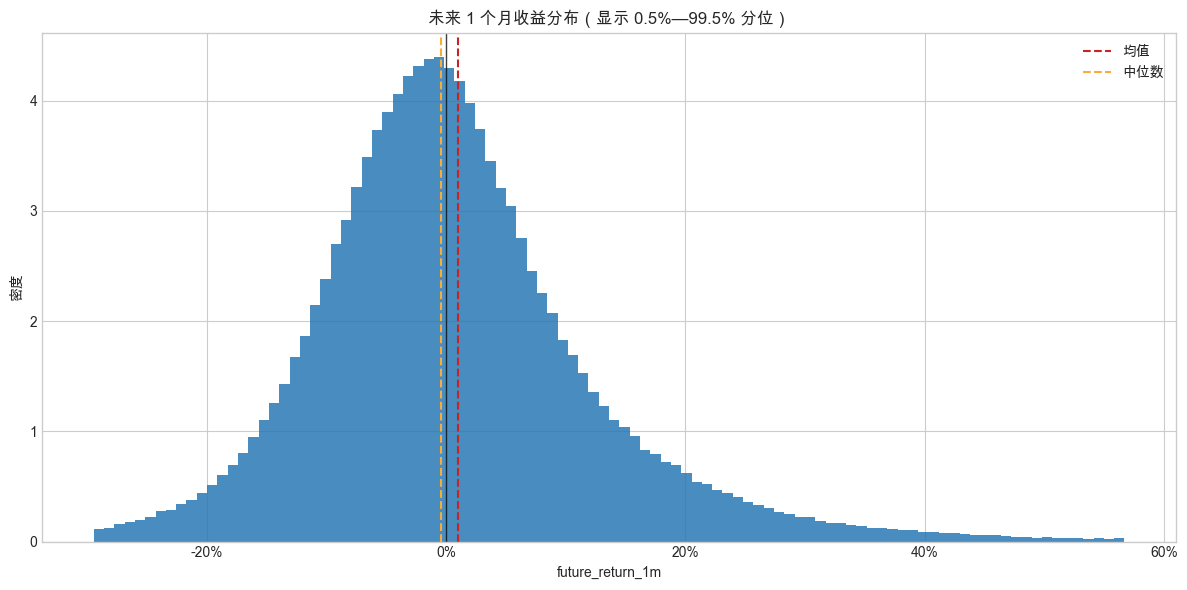

,value
观测数量,383891.000000
均值,0.009470
中位数,-0.004471
标准差,0.134009
0.5% 分位,-0.294668
99.5% 分位,0.567093
绝对收益 ≥ 20% 数量,35936.000000


图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/future_return_1m_distribution.png


In [10]:
returns = label_sample['future_return_1m']
display_lower, display_upper = returns.quantile([0.005, 0.995])
display_returns = returns.loc[returns.between(display_lower, display_upper)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(display_returns, bins=100, density=True, color='#2878B5', alpha=0.85)
ax.axvline(0, color='black', linewidth=1, alpha=0.7)
ax.axvline(returns.mean(), color='#C82423', linestyle='--', linewidth=1.5, label='均值')
ax.axvline(returns.median(), color='#F8AC3A', linestyle='--', linewidth=1.5, label='中位数')
ax.set_title('未来 1 个月收益分布（显示 0.5%—99.5% 分位）')
ax.set_xlabel('future_return_1m')
ax.set_ylabel('密度')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
fig.tight_layout()

future_return_distribution_path = FIGURES_DIRECTORY / 'future_return_1m_distribution.png'
fig.savefig(future_return_distribution_path, dpi=150, bbox_inches='tight')
plt.show()

return_distribution_summary = pd.Series({
    '观测数量': len(returns),
    '均值': returns.mean(),
    '中位数': returns.median(),
    '标准差': returns.std(ddof=1),
    '0.5% 分位': display_lower,
    '99.5% 分位': display_upper,
    '绝对收益 ≥ 20% 数量': returns.abs().ge(0.20).sum(),
})
display(return_distribution_summary.to_frame('value'))
print(f'图表已保存至：{future_return_distribution_path}')

### 11.2 每年月收益波动变化

年度波动率定义为该信号年份全部主样本 `future_return_1m` 的样本标准差，用来比较不同年份个股月收益的整体离散程度。它是横截面与月份合并后的描述性统计，不是策略净值的时间序列波动率。

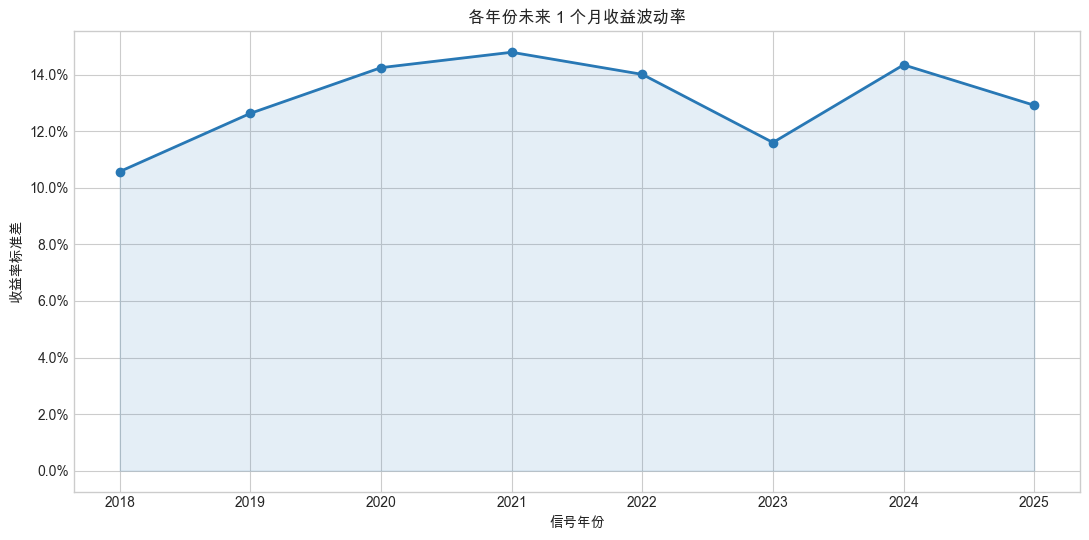

,year,observations,mean,volatility
0,2018,37252,-0.027382,0.105732
1,2019,40077,0.025204,0.126326
2,2020,41356,0.009328,0.142487
3,2021,46283,0.017232,0.147936
4,2022,52238,0.008716,0.140114
5,2023,55432,-0.016069,0.116022
6,2024,57567,0.021149,0.143483
7,2025,53686,0.031292,0.129181


图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/annual_monthly_return_volatility.png


In [11]:
annual_return_statistics = (
    label_sample.assign(year=label_sample['date'].dt.year)
    .groupby('year')['future_return_1m']
    .agg(observations='size', mean='mean', volatility='std')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(
    annual_return_statistics['year'],
    annual_return_statistics['volatility'],
    color='#2878B5', marker='o', linewidth=2,
)
ax.fill_between(
    annual_return_statistics['year'],
    0,
    annual_return_statistics['volatility'],
    color='#2878B5', alpha=0.12,
)
ax.set_title('各年份未来 1 个月收益波动率')
ax.set_xlabel('信号年份')
ax.set_ylabel('收益率标准差')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(annual_return_statistics['year'])
fig.tight_layout()

annual_volatility_path = FIGURES_DIRECTORY / 'annual_monthly_return_volatility.png'
fig.savefig(annual_volatility_path, dpi=150, bbox_inches='tight')
plt.show()
display(annual_return_statistics)
print(f'图表已保存至：{annual_volatility_path}')

### 11.3 横截面收益均值与标准差时间序列

每个信号月分别对当月全部主样本股票计算未来收益均值和标准差。均值反映该月股票整体方向，标准差反映个股收益分化。

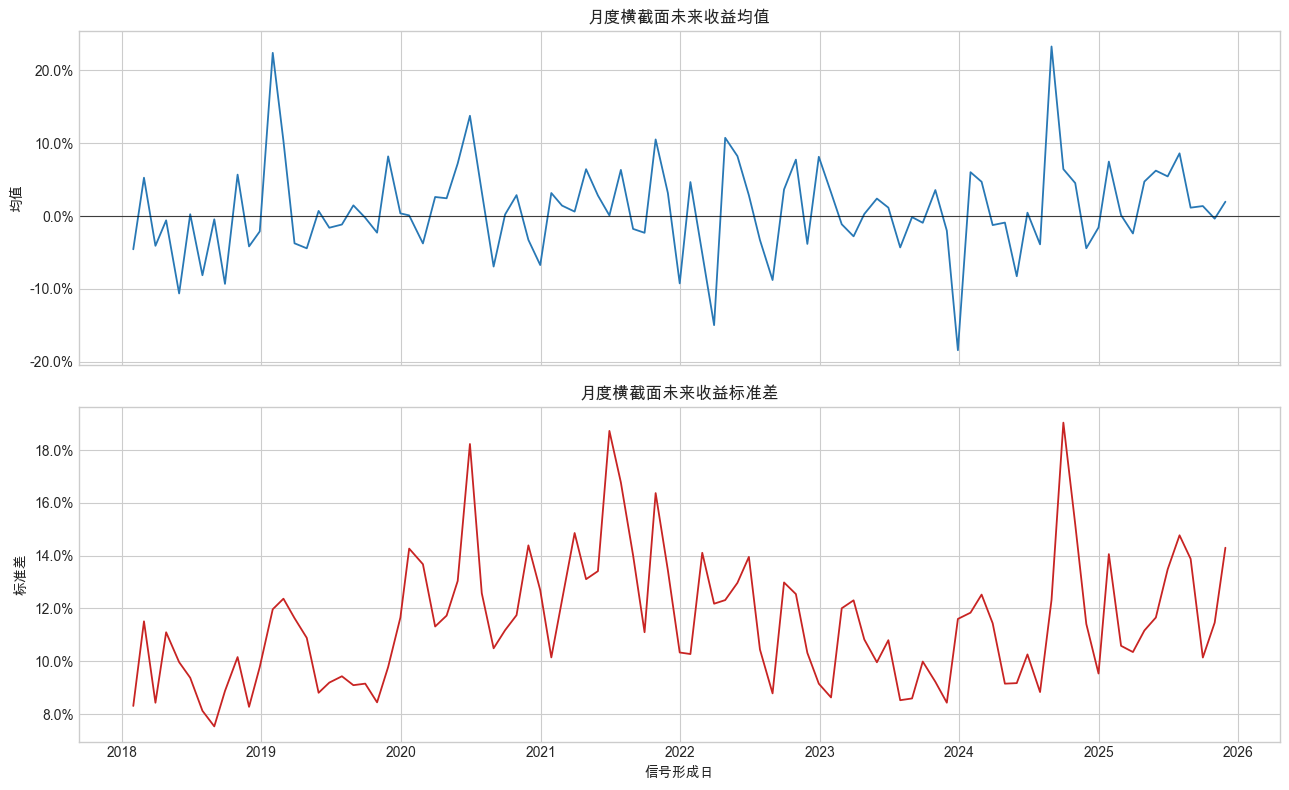

,date,stock_count,mean_return,return_std
90,2025-07-31,4884,0.086142,0.147719
91,2025-08-29,4903,0.011603,0.138803
92,2025-09-30,4905,0.013815,0.101432
93,2025-10-31,4918,-0.003503,0.114646
94,2025-11-28,4917,0.019770,0.143007


图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/cross_sectional_return_statistics.png


In [12]:
cross_sectional_return_statistics = (
    label_sample.groupby('date')['future_return_1m']
    .agg(stock_count='size', mean_return='mean', return_std='std')
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(
    cross_sectional_return_statistics['date'],
    cross_sectional_return_statistics['mean_return'],
    color='#2878B5', linewidth=1.3,
)
axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.7)
axes[0].set_title('月度横截面未来收益均值')
axes[0].set_ylabel('均值')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[1].plot(
    cross_sectional_return_statistics['date'],
    cross_sectional_return_statistics['return_std'],
    color='#C82423', linewidth=1.3,
)
axes[1].set_title('月度横截面未来收益标准差')
axes[1].set_xlabel('信号形成日')
axes[1].set_ylabel('标准差')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.tight_layout()

cross_sectional_statistics_path = (
    FIGURES_DIRECTORY / 'cross_sectional_return_statistics.png'
)
fig.savefig(cross_sectional_statistics_path, dpi=150, bbox_inches='tight')
plt.show()
display(cross_sectional_return_statistics.tail())
print(f'图表已保存至：{cross_sectional_statistics_path}')

### 11.4 不同年份股票数量与标签缺失率

柱形分别表示每年平均月度候选股票数和平均月度主研究样本数。股票数量和缺失率都只统计具有下一调仓日的月份；样本最后一个月的结构性右截断不参与年度比较。折线表示这些非右截断记录中 `future_return_1m` 不可用的比例。

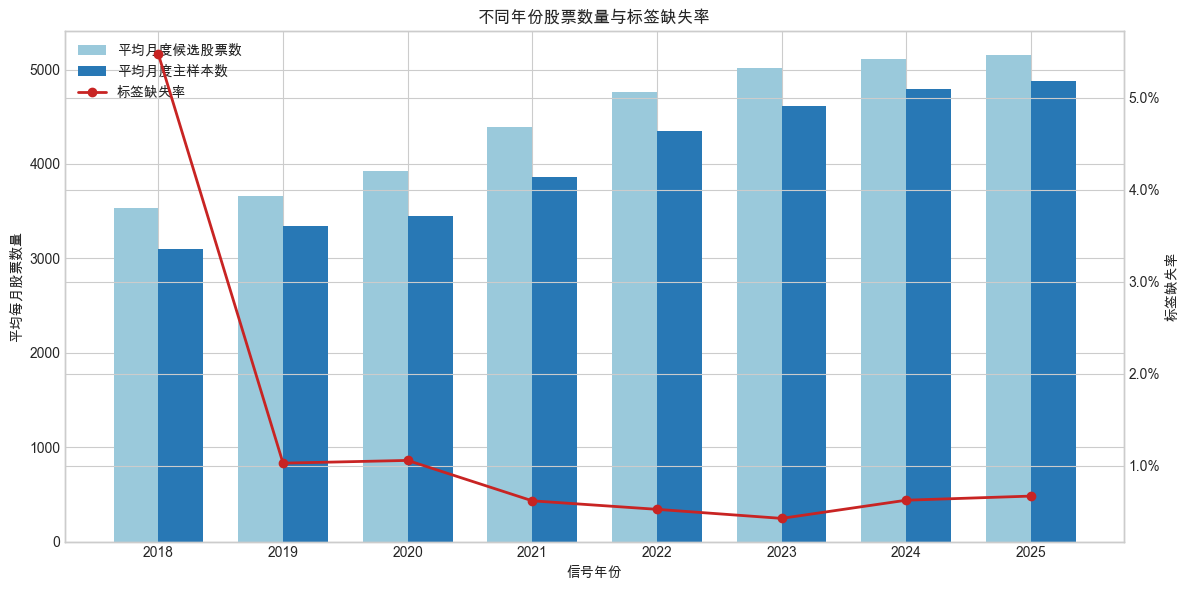

,year,average_monthly_candidates,average_monthly_label_sample,label_missing_rate
0,2018,3529.833333,3104.333333,0.0547
1,2019,3656.000000,3339.75,0.010303
2,2020,3931.000000,3446.333333,0.0106
3,2021,4387.083333,3856.916667,0.006211
4,2022,4759.333333,4353.166667,0.005288
5,2023,5013.916667,4619.333333,0.004305
6,2024,5109.750000,4797.25,0.006279
7,2025,5149.818182,4880.545455,0.006726


图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/yearly_stock_count_and_label_missing_rate.png


In [13]:
non_boundary_panel = monthly_panel.loc[
    monthly_panel['label_status'].ne('right_censored')
].copy()
monthly_stock_counts = (
    non_boundary_panel.groupby('date')
    .agg(
        candidate_stocks=('stock_code', 'size'),
        label_sample_stocks=('is_in_label_sample', 'sum'),
    )
    .reset_index()
)
yearly_stock_counts = (
    monthly_stock_counts.assign(year=monthly_stock_counts['date'].dt.year)
    .groupby('year')
    .agg(
        average_monthly_candidates=('candidate_stocks', 'mean'),
        average_monthly_label_sample=('label_sample_stocks', 'mean'),
    )
)

yearly_label_missing_rate = (
    non_boundary_panel.assign(
        year=non_boundary_panel['date'].dt.year,
        label_missing=~non_boundary_panel['label_available'],
    )
    .groupby('year')['label_missing']
    .mean()
    .rename('label_missing_rate')
)
yearly_coverage = yearly_stock_counts.join(yearly_label_missing_rate).reset_index()

x = np.arange(len(yearly_coverage))
bar_width = 0.36
fig, count_axis = plt.subplots(figsize=(12, 6))
count_axis.bar(
    x - bar_width / 2,
    yearly_coverage['average_monthly_candidates'],
    width=bar_width, label='平均月度候选股票数', color='#9AC9DB',
)
count_axis.bar(
    x + bar_width / 2,
    yearly_coverage['average_monthly_label_sample'],
    width=bar_width, label='平均月度主样本数', color='#2878B5',
)
count_axis.set_xlabel('信号年份')
count_axis.set_ylabel('平均每月股票数量')
count_axis.set_xticks(x, yearly_coverage['year'])

missing_axis = count_axis.twinx()
missing_axis.plot(
    x, yearly_coverage['label_missing_rate'],
    color='#C82423', marker='o', linewidth=2, label='标签缺失率',
)
missing_axis.set_ylabel('标签缺失率')
missing_axis.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

handles_1, labels_1 = count_axis.get_legend_handles_labels()
handles_2, labels_2 = missing_axis.get_legend_handles_labels()
count_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left')
count_axis.set_title('不同年份股票数量与标签缺失率')
fig.tight_layout()

yearly_coverage_path = (
    FIGURES_DIRECTORY / 'yearly_stock_count_and_label_missing_rate.png'
)
fig.savefig(yearly_coverage_path, dpi=150, bbox_inches='tight')
plt.show()
display(yearly_coverage)
print(f'图表已保存至：{yearly_coverage_path}')